In [19]:
from QSM.solver import find_trim_angle
from QSM.forces import calculate_tether_force, calculate_tangential_force
from QSM.velocities import calculate_kite_speed
import pandas as pd
import numpy as np

mass = 55
wing_area = 19.5

# File path
csv_file = '../processed_data/aerodynamic_polars_v3.csv'

# Read the CSV file
data = pd.read_csv(csv_file)
alpha_tether_wing = np.radians(5)
alpha_curve = data['angle_of_attack']
cl_curve = data['lift_coefficient']
cd_curve = data['drag_coefficient']

In [20]:
# Solve Lloyd condition and trim angle of attack
alpha_trim_kite = find_trim_angle(alpha_curve, cl_curve, cd_curve)
CL_trim = np.interp(alpha_trim_kite, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim_kite, alpha_curve, cd_curve)
print(f'Trim angle of attack: {np.degrees(alpha_trim_kite)} deg')
print(f'Trim lift coefficient: {CL_trim}')
print(f'Trim drag coefficient: {CD_trim}')



Trim angle of attack: [5.42610631] deg
Trim lift coefficient: [0.63338107]
Trim drag coefficient: [0.11811333]


(0.0, 20.0)

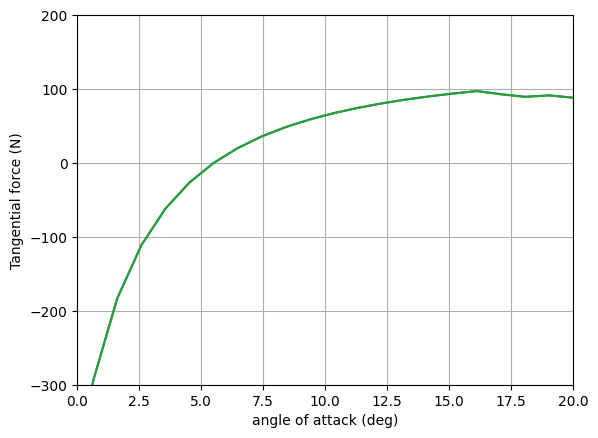

In [21]:
import matplotlib.pyplot as plt

azimuth = -10
elevation = np.radians(30)
headings = np.radians(np.linspace(-90, 90, 3))
reelout_speed = 1
wind_speed = 1

plt.figure()
for heading in headings:
    # Calculate the tangential force
    ftan = calculate_tangential_force(alpha_curve,cl_curve,cd_curve,azimuth, elevation, reelout_speed, wind_speed, wing_area, mass = mass, heading = heading)
    plt.plot(np.degrees(alpha_curve), ftan, label=f'Wind speed = {wind_speed} m/s')

plt.xlabel('angle of attack (deg)')
plt.ylabel('Tangential force (N)')
plt.grid()
plt.ylim(-300,200)
plt.xlim(0,20)

In [22]:
# Solve specific condition with weight
angle_tether_kcu = np.radians(0.0)
azimuth = np.radians(20.0)
elevation = np.radians(40)+angle_tether_kcu
heading = np.radians(80)
#alpha_tether_wing = np.radians(14)
wind_speed = 8
reelout_speed = 1.4
#alpha_curve = data['angle_of_attack']+alpha_tether_wing


#cd_curve -=0.1
alpha_trim = find_trim_angle(alpha_curve, 
                            cl_curve,
                            cd_curve,
                            wind_speed=wind_speed,
                            reelout_speed=reelout_speed,
                            azimuth=azimuth,
                            elevation=elevation,
                            mass=mass,
                            wing_area=wing_area,
                            heading=heading)
CL_trim = np.interp(alpha_trim, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim, alpha_curve, cd_curve)
print(f'Alpha trim: {np.degrees(alpha_trim)} deg')
print(f'CL trim: {CL_trim}')
print(f'CD trim: {CD_trim}')
alpha_trim = alpha_tether_wing + alpha_trim



kite_speed = calculate_kite_speed(alpha_trim,azimuth, elevation, reelout_speed, wind_speed, heading=heading)
tether_force = calculate_tether_force(alpha_trim,CL_trim,CD_trim,azimuth, elevation, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)


print(f'Kite speed: {kite_speed} m/s')
print(f'Tether force: {tether_force} N')




Alpha trim: [6.04171098] deg
CL trim: [0.68230483]
CD trim: [0.12136775]
Kite speed: [25.18675208] m/s
Tether force: [3879.49744553] N


Trim angle of attack: [6.68516786] deg


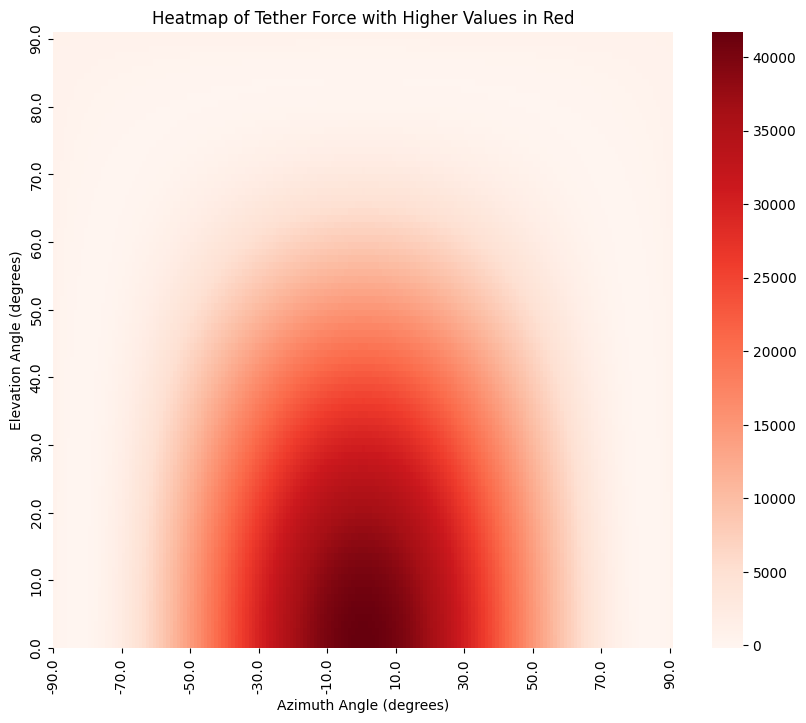

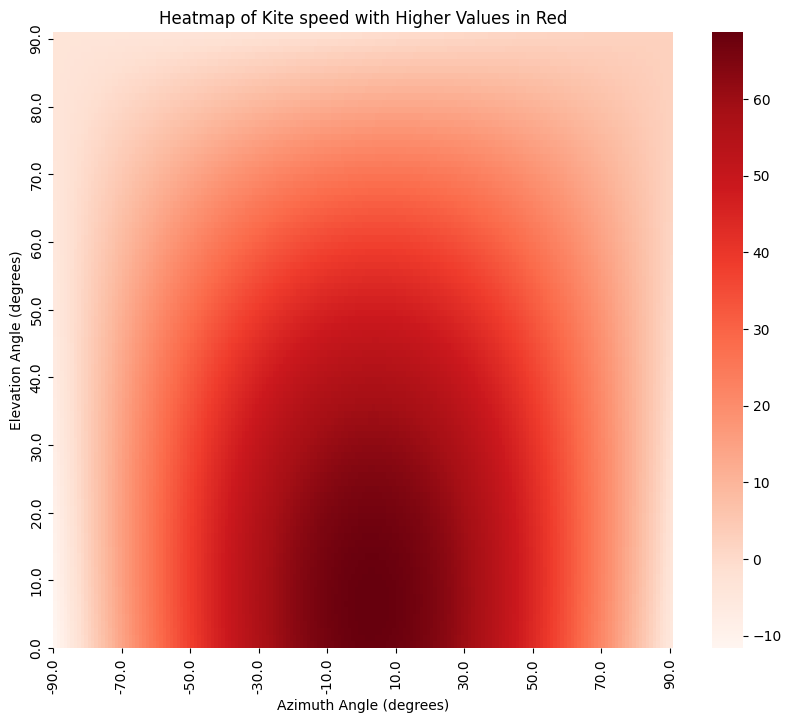

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
## Plot wind window for 0 yaw angle
azimuth = np.radians(0.0)
elevation = np.radians(0)+angle_tether_kcu
heading = np.radians(20)

wind_speed = 9
reelout_speed = 1

alpha_trim = find_trim_angle(alpha_curve, 
                            cl_curve,
                            cd_curve,
                            wind_speed=wind_speed,
                            reelout_speed=reelout_speed,
                            azimuth=azimuth,
                            elevation=elevation,
                            mass=mass,
                            wing_area=wing_area,
                            heading=heading)
print(f'Trim angle of attack: {np.degrees(alpha_trim)} deg')
CL_trim = np.interp(alpha_trim, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim, alpha_curve, cd_curve)
#alpha_trim = alpha_tether_wing + alpha_trim
# Elevation and azimuth angles in radians
elevation_angle = np.linspace(0, 90, 91) * np.pi / 180
azimuth_angle = np.linspace(-90, 90, 181) * np.pi / 180

# Create meshgrid for elevation and azimuth angles
azimuth_grid, elevation_grid = np.meshgrid(azimuth_angle,elevation_angle)

kite_speed = calculate_kite_speed(alpha_trim,azimuth_grid, elevation_grid, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim,CL_trim,CD_trim,azimuth_grid, elevation_grid, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(tether_force,cmap="Reds")
# Set the number of ticks
num_ticks = 10
plt.xticks(ticks=np.linspace(0, len(np.sin(azimuth_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(-90, 90, num_ticks), 1))
plt.yticks(ticks=np.linspace(0, len(np.sin(elevation_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(0, 90, num_ticks), 1))
# Invert the y-axis
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Heatmap of Tether Force with Higher Values in Red')
plt.xlabel('Azimuth Angle (degrees)')
plt.ylabel('Elevation Angle (degrees)')
plt.show()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(kite_speed,cmap="Reds")
# Set the number of ticks
num_ticks = 10
plt.xticks(ticks=np.linspace(0, len(np.sin(azimuth_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(-90, 90, num_ticks), 1))
plt.yticks(ticks=np.linspace(0, len(np.sin(elevation_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(0, 90, num_ticks), 1))
# Invert the y-axis
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Heatmap of Kite speed with Higher Values in Red')
plt.xlabel('Azimuth Angle (degrees)')
plt.ylabel('Elevation Angle (degrees)')
plt.show()


Text(0, 0.5, 'Kite speed (m/s)')

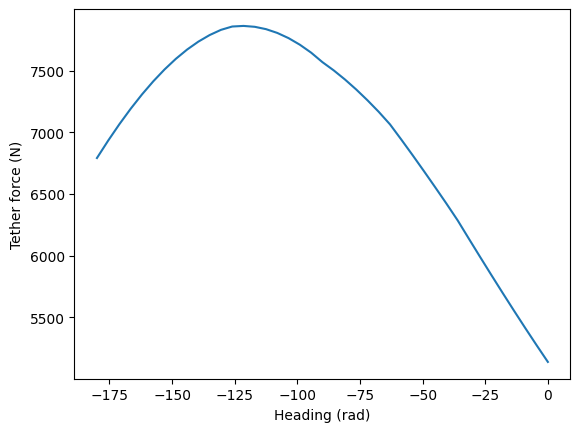

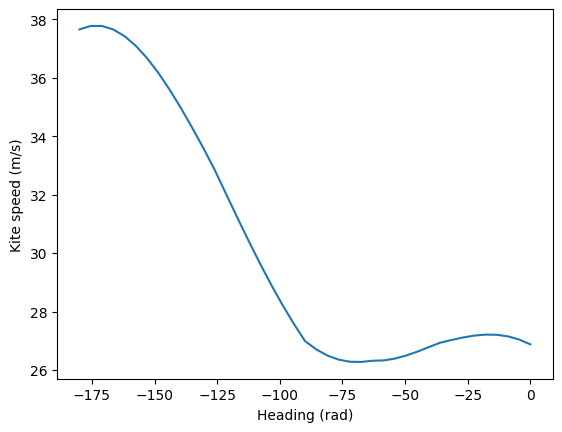

In [24]:
#Calculate forces along a circle
# Define heading, azimuth and elevation angles in radians
headings = np.radians(np.linspace(0, -90, 21))
# Azimuth from 0 to 20 to 0 to -20
azimuths = np.radians(np.linspace(0, 20, 21))
elevation = np.radians(np.linspace(40, 30, 21))
azimuths = np.concatenate((azimuths, azimuths[::-1]))
elevation = np.concatenate((elevation, elevation[::-1]))
headings = np.concatenate((headings, np.radians(np.linspace(-90, -180, 21))))
wind_speed = 8
tether_force = []
kite_speed = []
for i in range(len(headings)):
    # Calculate the tangential force
    alpha_trim = find_trim_angle(alpha_curve, cl_curve, cd_curve, wind_speed=wind_speed, reelout_speed=reelout_speed, azimuth=azimuths[i], elevation=elevation[i], mass=mass, wing_area=wing_area, heading=headings[i])
    CL_trim = np.interp(alpha_trim, alpha_curve, cl_curve)
    CD_trim = np.interp(alpha_trim, alpha_curve, cd_curve)
    alpha_trim = alpha_tether_wing + alpha_trim
    kite_speed.append(calculate_kite_speed(alpha_trim, azimuths[i], elevation[i], reelout_speed, wind_speed, heading=headings[i]))
    tether_force.append(calculate_tether_force(alpha_trim, CL_trim, CD_trim, azimuths[i], elevation[i], reelout_speed, wind_speed, kite_speed[i], wing_area, mass=mass, heading=headings[i]))

plt.figure()
plt.plot(np.degrees(headings), tether_force)
plt.xlabel('Heading (rad)')
plt.ylabel('Tether force (N)')

plt.figure()
plt.plot(np.degrees(headings), kite_speed)
plt.xlabel('Heading (rad)')
plt.ylabel('Kite speed (m/s)')